In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import camb
import scipy.interpolate as interp
from camb import model, initialpower

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
sigma 8 values at the two redshifts (fiducial): [0.54435417 0.79538453]
sigma 8 values at the two redshifts (modified): [0.62199161 0.83319921]


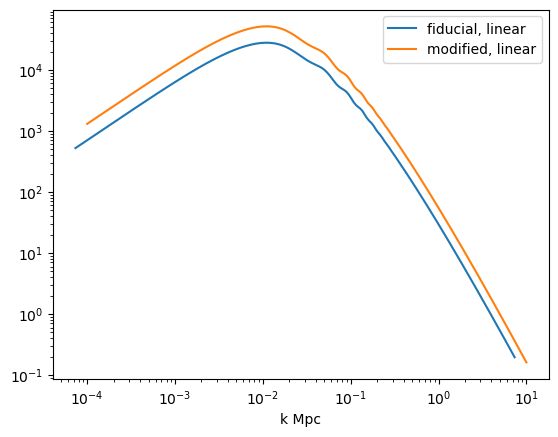

In [ ]:
# Now get matter power spectra and sigma8 at redshift 0 and 0.8
# parameters can all be passed as a dict as above, or you can call
# separate functions to set up the parameter object
H0_1 = 73.5
H0_2 = 100
h1 = H0_1/100
h2 = H0_2/100

pars1 = camb.set_params(H0=H0_1, ombh2=0.0225, omch2=0.1174, ns=0.969)
pars2 = camb.set_params(H0=H0_2, ombh2=0.0225, omch2=0.1174, ns=0.969)
# Note non-linear corrections couples to smaller scales than you want
z1 = np.linspace(0,0.8,2)
z2 = np.linspace(0,0.8,2)
pars1.set_matter_power(z1, kmax=10.0)
pars2.set_matter_power(z2, kmax=10.0)
# Linear spectra
pars1.NonLinear = model.NonLinear_none
pars2.NonLinear = model.NonLinear_none
results1 = camb.get_results(pars1)
results2 = camb.get_results(pars2)
kh1, z1, pk1 = results1.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)
kh2, z2, pk2 = results2.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)
# s8 = np.array(results.get_sigma8())

# # Non-Linear spectra (Halofit)
pars1.NonLinear = model.NonLinear_both
pars2.NonLinear = model.NonLinear_both
results1.calc_power_spectra(pars1)
results2.calc_power_spectra(pars2)
kh_nonlin1, z_nonlin1, pk_nonlin1 = results1.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)
kh_nonlin2, z_nonlin2, pk_nonlin2 = results2.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)

print('sigma 8 values at the two redshifts (fiducial):', results1.get_sigma8())
print('sigma 8 values at the two redshifts (modified):', results2.get_sigma8())
kh1 = kh1*h1
kh2 = kh2*h2
# kh_nonlin1 = kh_nonlin1*h1
# kh_nonlin2 = kh_nonlin2*h2
# pk1 = pk1 * h1**3
# pk2 = pk2 * h2**3
# pk_nonlin1 = pk_nonlin1 * h1**3
# pk_nonlin2 = pk_nonlin2 * h2**3
plt.loglog(kh1,pk1[0],label="fiducial, linear")
plt.loglog(kh2,pk2[0],label="modified, linear")
# plt.loglog(kh_nonlin1,pk_nonlin1[0],label="fiducial, nonlinear"
#         #    , marker = '.'
#            )
# plt.loglog(kh_nonlin2,pk_nonlin2[0],label="modified, nonlinear"
#         #    , marker = '.'
#            )
# plt.loglog(kh,)
plt.xlabel('k Mpc')
plt.legend();

== model1 H0=73.5 ==
h = 0.735, omega_m = 0.1399, Omega_m = 0.258966
sigma8(z=0) =  [0.15138105 0.15224956 0.15312807 0.15401675 0.15491578 0.15582535
 0.15674563 0.15767682 0.15861912 0.15957271 0.16053781 0.16151461
 0.16250334 0.16350422 0.16451745 0.16554329 0.16658195 0.16763368
 0.16869872 0.16977733 0.17086977 0.1719763  0.1730972  0.17423273
 0.1753832  0.17654889 0.1777301  0.17892715 0.18014035 0.18137002
 0.18261651 0.18388015 0.18516129 0.18646031 0.18777756 0.18911345
 0.19046835 0.19184267 0.19323684 0.19465126 0.1960864  0.19754268
 0.19902059 0.2005206  0.20204321 0.20358891 0.20515823 0.20675172
 0.20836991 0.21001339 0.21168274 0.21337856 0.21510148 0.21685215
 0.21863122 0.22043938 0.22227734 0.22414583 0.22604559 0.2279774
 0.22994207 0.23194042 0.2339733  0.23604159 0.23814622 0.24028812
 0.24246826 0.24468765 0.24694734 0.24924839 0.25159194 0.25397912
 0.25641114 0.25888922 0.26141465 0.26398876 0.26661292 0.26928855
 0.27201713 0.27480018 0.27763929 0.2805361  0

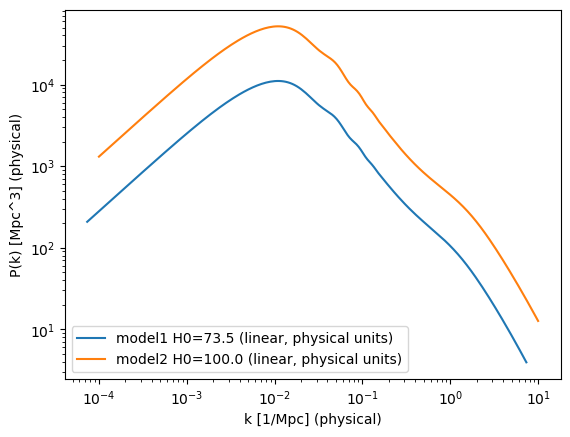

In [5]:
# --- diagnostics and replot in physical units ---
import numpy as np
import matplotlib.pyplot as plt

def diagnostics_and_replot(results, pars, label):
    H0 = pars.H0 if hasattr(pars,'H0') else pars.get('H0', None)
    # H0 in km/s/Mpc in your set_params; compute h
    h = float(pars.H0) / 100.0 if hasattr(pars,'H0') else float(pars['H0'])/100.0
    # physical omegas you passed:
    ombh2 = float(pars.ombh2) if hasattr(pars,'ombh2') else float(pars['ombh2'])
    omch2 = float(pars.omch2) if hasattr(pars,'omch2') else float(pars['omch2'])
    omega_m = ombh2 + omch2
    Omega_m = omega_m / (h**2)

    print(f"== {label} ==")
    print("h = %.6g, omega_m = %.6g, Omega_m = %.6g" % (h, omega_m, Omega_m))
    # sigma8 at z=0
    try:
        s8_0 = results.get_sigma8()    # typical CAMB API returns sigma8 at z=0
    except TypeError:
        # Some CAMB wrappers expect args; fallback:
        s8_0 = results.get_sigma8(0.0)
    print("sigma8(z=0) = ", s8_0)

    # sigma8 at z=0.8: try CAMB API, otherwise scale by linear growth factor
    s8_08 = None
    try:
        s8_08 = results.get_sigma8(0.8)
        print("sigma8(z=0.8) [CAMB] = ", s8_08)
    except Exception:
        # fallback: scale by growth factor if available
        try:
            Dz = results.get_linear_growth_factor(0.8)
            D0 = results.get_linear_growth_factor(0.0)
            s8_08 = s8_0 * Dz / D0
            print("sigma8(z=0.8) [scaled] = ", s8_08)
        except Exception:
            print("Couldn't get sigma8 at z=0.8 via CAMB API or growth-factor scaling.")

    # get matter power arrays (assumes results already computed)
    kh, zlist, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=200)
    # kh in h/Mpc, pk in (Mpc/h)^3 (CAMB convention) -> convert to physical units:
    k_phys = kh * h                   # 1/Mpc
    pk_phys = pk * (h**3)             # Mpc^3

    return h, k_phys, pk_phys

h1, k_phys1, pk_phys1 = diagnostics_and_replot(results1, pars1, 'model1 H0=%.1f' % pars1.H0)
h2, k_phys2, pk_phys2 = diagnostics_and_replot(results2, pars2, 'model2 H0=%.1f' % pars2.H0)

# Replot in physical units (k [1/Mpc], P(k) [Mpc^3])
plt.figure()
plt.loglog(k_phys1, pk_phys1[0], label=f"model1 H0={pars1.H0} (linear, physical units)")
plt.loglog(k_phys2, pk_phys2[0], label=f"model2 H0={pars2.H0} (linear, physical units)")
plt.xlabel('k [1/Mpc] (physical)')
plt.ylabel('P(k) [Mpc^3] (physical)')
plt.legend()
plt.show()


Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


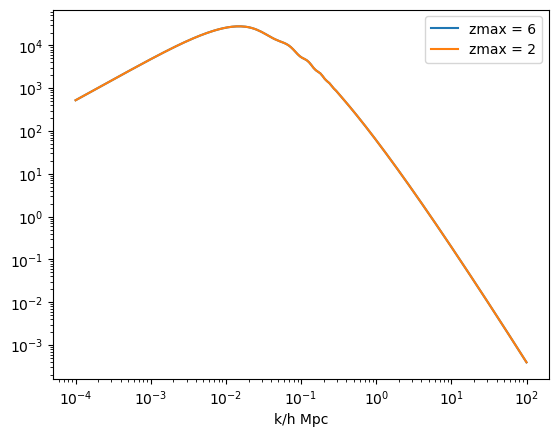

In [15]:
# Now get matter power spectra and sigma8 at redshift 0 and 0.8
# parameters can all be passed as a dict as above, or you can call
# separate functions to set up the parameter object
pars1 = camb.set_params(H0=73.5, ombh2=0.0225, omch2=0.1174+1e-6, ns=0.969)
pars2 = camb.set_params(H0=73.5, ombh2=0.0225, omch2=0.1174, ns=0.969)
# Note non-linear corrections couples to smaller scales than you want
z1 = np.linspace(0,6,150)
z2 = np.linspace(0,2,150)
pars1.set_matter_power(z1, kmax=100.0)
pars2.set_matter_power(z2, kmax=100.0)

# Linear spectra
pars1.NonLinear = model.NonLinear_none
pars2.NonLinear = model.NonLinear_none
results1 = camb.get_results(pars1)
results2 = camb.get_results(pars2)
kh, z1, pk1 = results1.get_matter_power_spectrum(minkh=1e-4, maxkh=100, npoints=200)
kh, z2, pk2 = results2.get_matter_power_spectrum(minkh=1e-4, maxkh=100, npoints=200)
# s8 = np.array(results.get_sigma8())

# # Non-Linear spectra (Halofit)
pars1.NonLinear = model.NonLinear_both
pars2.NonLinear = model.NonLinear_both
results1.calc_power_spectra(pars1)
results2.calc_power_spectra(pars2)
kh_nonlin1, z_nonlin1, pk_nonlin1 = results1.get_matter_power_spectrum(minkh=1e-4, maxkh=100, npoints=200)
kh_nonlin2, z_nonlin2, pk_nonlin2 = results2.get_matter_power_spectrum(minkh=1e-4, maxkh=100, npoints=200)

# print('sigma 8 values at the two redshifts:', results.get_sigma8())

plt.loglog(kh,pk1[0],label="zmax = 6")
plt.loglog(kh,pk2[0],label="zmax = 2")
# plt.loglog(kh_nonlin1,pk_nonlin1[0],label="zmax = 6, nonlin", marker = '.')
# plt.loglog(kh_nonlin2,pk_nonlin2[0],label="zmax = 2, nonlin", marker = '.')
# plt.loglog(kh,)
plt.xlabel('k/h Mpc')
plt.legend();

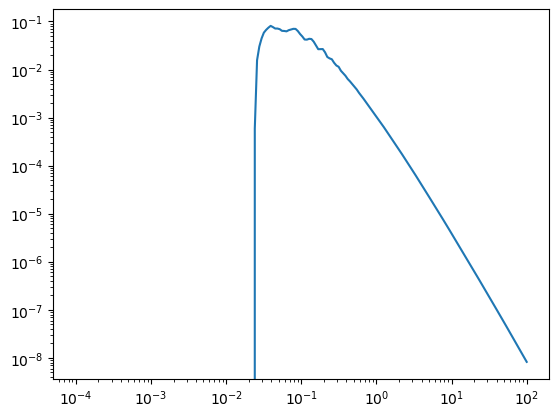

In [18]:
plt.loglog(kh,(pk1-pk2)[0])

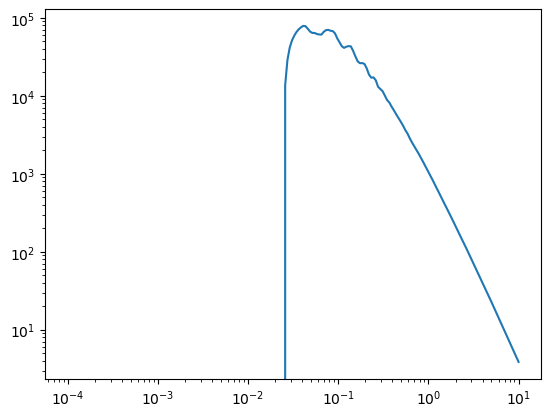

In [14]:
plt.loglog(kh,(pk1-pk2)[0]/1e-6)

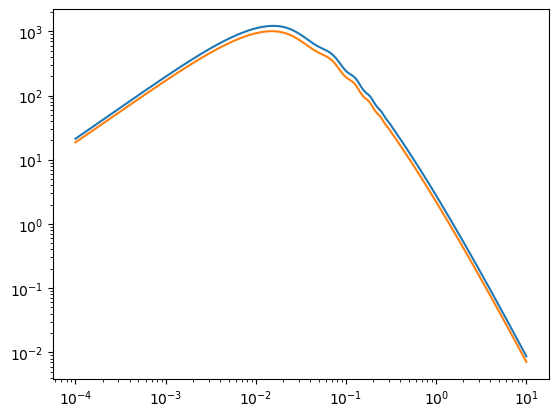

In [21]:
pm0 = np.loadtxt("pm0.txt")
kpre = np.loadtxt("k_pre_ext.txt")
pm0_interp = interp.InterpolatedUnivariateSpline(kpre,pm0)

pm0 = pm0_interp(kh)
plt.loglog(kh,pm0)
plt.loglog(kh,pk1[-1])

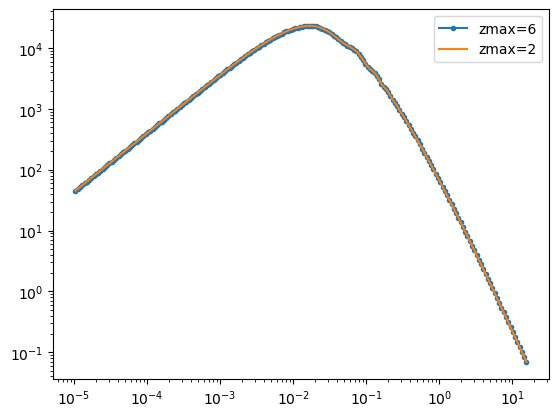

In [25]:
tt = 'delta_tot'
pk1,zcalc1,kcalc1 = results1.get_matter_power_interpolator(nonlinear = False, var1 = tt, var2 = tt, return_z_k=True)
pk2,zcalc2,kcalc2 = results2.get_matter_power_interpolator(nonlinear = False, var1 = tt, var2 = tt, return_z_k=True)
assert pk1.islog
assert pk2.islog
k1 = np.logspace(np.log10(kcalc1[0]), np.log10(kcalc1[-1]), 200)
k2 = np.logspace(np.log10(kcalc2[0]), np.log10(kcalc2[-1]), 200)
pk1 = pk1.P(z1, k1, grid=True)
pk2 = pk2.P(z2, k2, grid=True)

plt.loglog(k1,pk1[0],label="zmax=6",marker='.')
plt.loglog(k1,pk2[0],label="zmax=2")
plt.legend()

In [45]:
pz2.shape

(150, 200)

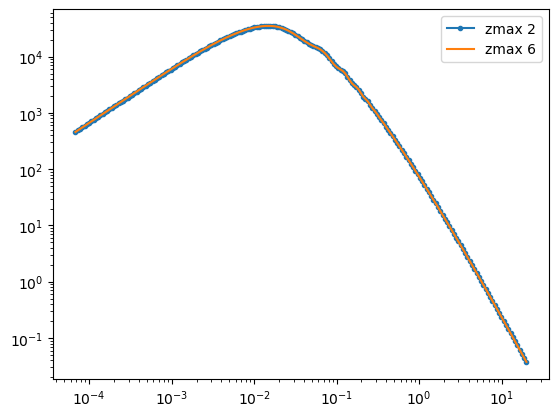

In [69]:
k2 = np.loadtxt("k2.txt")
k6 = np.loadtxt("k6.txt")
pz2 = np.loadtxt("pm_testz2.txt")
pz6 = np.loadtxt("pm_testz6.txt")

plt.loglog(k2,pz2[0],label="zmax 2", marker='.')
plt.loglog(k6,pz6[0],label="zmax 6")
plt.legend()

True
(150, 399)


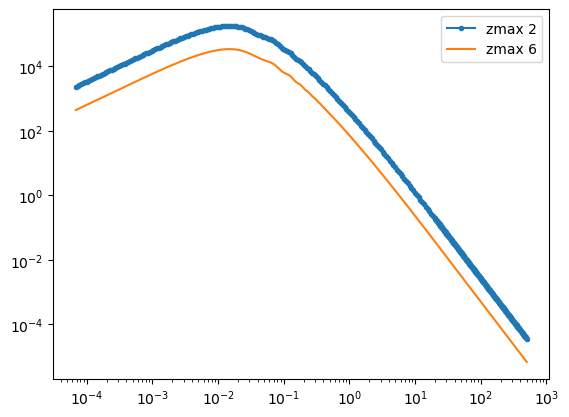

In [76]:
k2 = np.loadtxt("k_ext_z2.txt")
k6 = np.loadtxt("k_ext_z6.txt")
pz2 = np.loadtxt("pm_ext_z2.txt")
pz6 = np.loadtxt("pm_ext_z6.txt")
print(np.all(k2 == k6))
print(pz2.shape)
plt.loglog(k2,pz2[0],label="zmax 2", marker='.')
plt.loglog(k6,pz6[0],label="zmax 6")
plt.legend()

In [65]:
np.all(pout2 == pz2)

True

(150, 399)


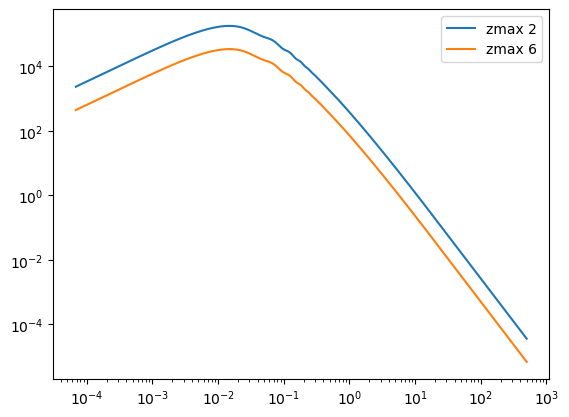

In [61]:
pout2 = np.loadtxt("P_out_z2.txt")
pout6 = np.loadtxt("P_out_z6.txt")
print(pout2.shape)
plt.loglog(k2,pout2[0],label="zmax 2")
plt.loglog(k6,pout6[0],label="zmax 6")
plt.legend()

In [63]:
test = np.dstack(pout2).squeeze()
test.shape

(399, 150)

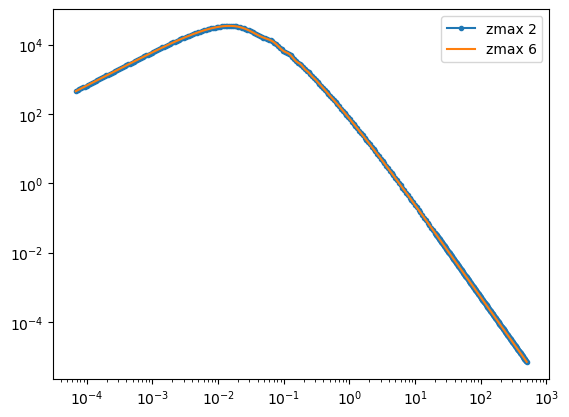

In [78]:
p2 = np.loadtxt("pz2.txt")
p6 = np.loadtxt("pz6.txt")
plt.loglog(k2,p2[0],label="zmax 2",marker='.')
plt.loglog(k6,p6[0],label="zmax 6")
plt.legend()